# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN

# Read & Understanding Data

In [6]:
df = pd.read_csv(r"E:\DataSets\Heart_disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100000,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600000,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900000,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4841,63,1,2,174,281,0,0,154,0,0.848749,1,0,3,0
4842,59,1,1,140,184,0,0,155,0,2.804466,1,0,2,0
4843,53,1,0,123,282,0,1,95,1,2.000000,1,2,3,0
4844,58,1,1,112,230,0,0,164,0,2.326788,1,1,3,0


In [7]:
df.shape

(4846, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       4846 non-null   int64  
 1   sex       4846 non-null   int64  
 2   cp        4846 non-null   int64  
 3   trestbps  4846 non-null   int64  
 4   chol      4846 non-null   int64  
 5   fbs       4846 non-null   int64  
 6   restecg   4846 non-null   int64  
 7   thalach   4846 non-null   int64  
 8   exang     4846 non-null   int64  
 9   oldpeak   4846 non-null   float64
 10  slope     4846 non-null   int64  
 11  ca        4846 non-null   int64  
 12  thal      4846 non-null   int64  
 13  target    4846 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 530.2 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,4846.000000,4846.00000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000,4846.000000
mean,56.097400,0.76558,0.498349,133.448411,249.419934,0.116178,0.369170,140.742262,0.409410,1.512251,1.111019,0.913950,2.403013,0.108543
std,7.746713,0.42368,0.862651,17.655262,50.224019,0.320472,0.507234,22.938195,0.491776,1.225896,0.583621,0.957628,0.686283,0.311097
min,29.000000,0.00000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,52.000000,1.00000,0.000000,120.000000,212.000000,0.000000,0.000000,125.000000,0.000000,0.525232,1.000000,0.000000,2.000000,0.000000
50%,57.000000,1.00000,0.000000,130.000000,246.000000,0.000000,0.000000,143.000000,0.000000,1.400000,1.000000,1.000000,3.000000,0.000000
75%,61.000000,1.00000,1.000000,142.000000,283.000000,0.000000,1.000000,159.000000,1.000000,2.200000,1.000000,2.000000,3.000000,0.000000
max,77.000000,1.00000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Numerical & Categorical Features

In [11]:
numerical_features = ['age','trestbps','chol','thalach','oldpeak']

categorical_features = [
'sex','cp','fbs','restecg','exang','slope','ca','thal'
]

target = 'target'

# Data Visualization

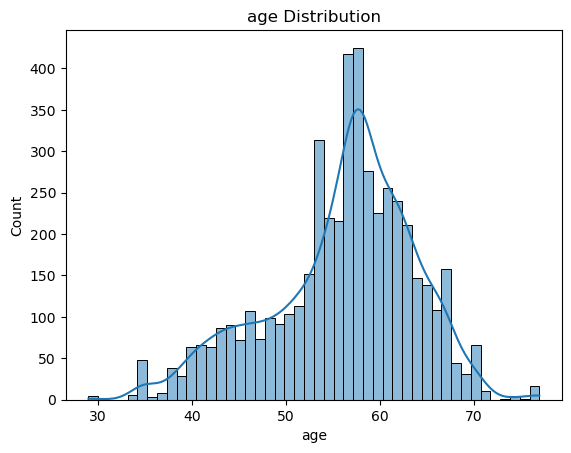

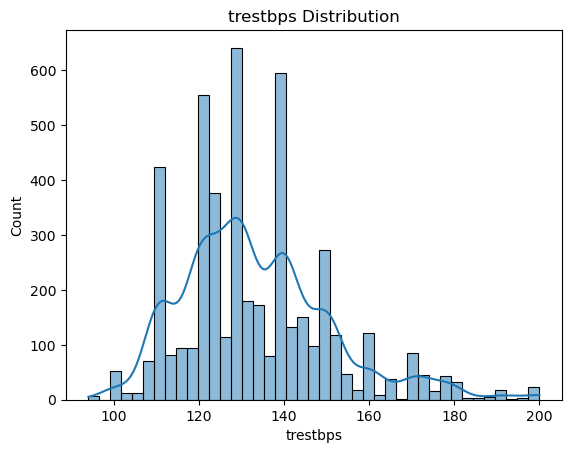

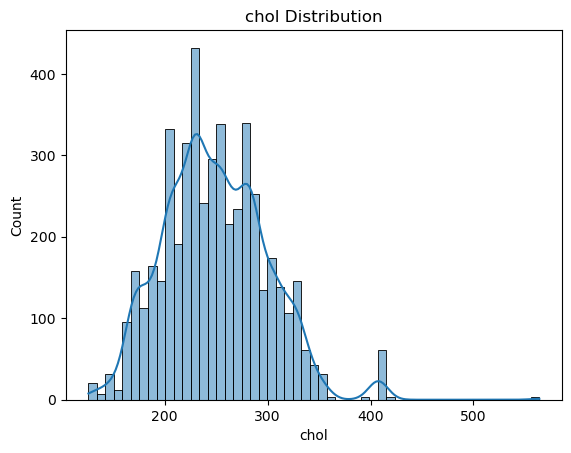

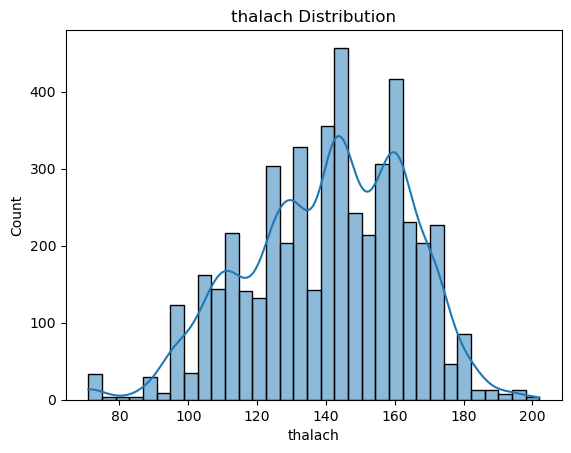

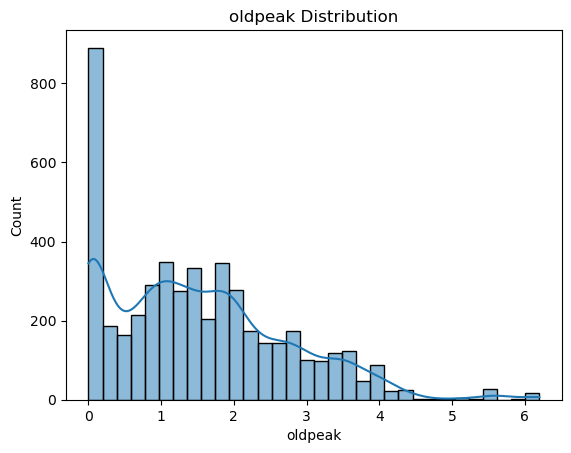

In [12]:
for col in numerical_features:
    
    plt.figure()
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"{col} Distribution")
    
    plt.show()

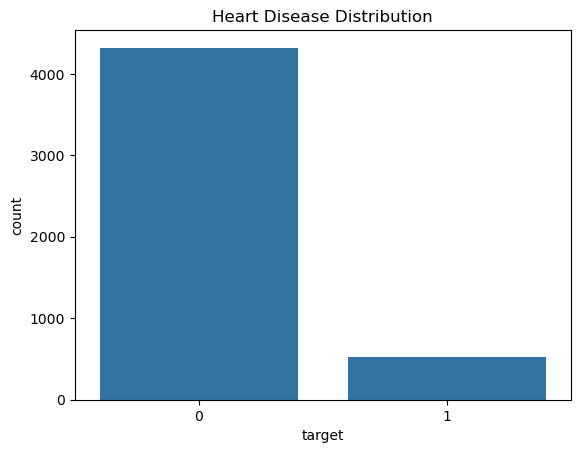

In [13]:
plt.figure()

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")

plt.show()

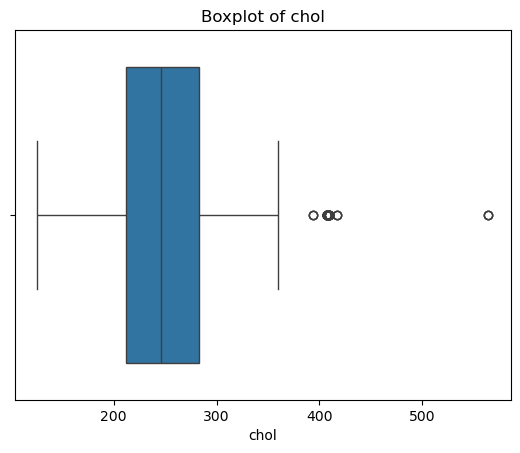

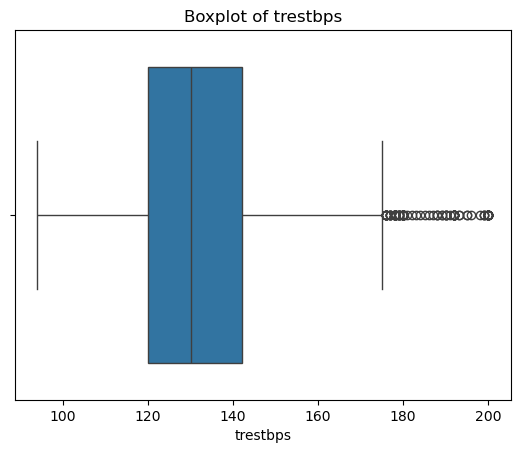

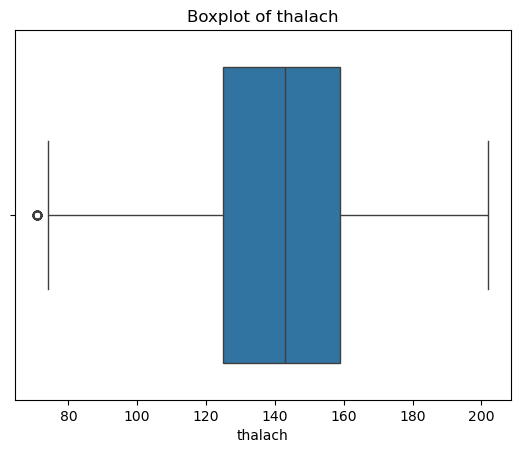

In [14]:
for col in ['chol','trestbps','thalach']:
    
    plt.figure()
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

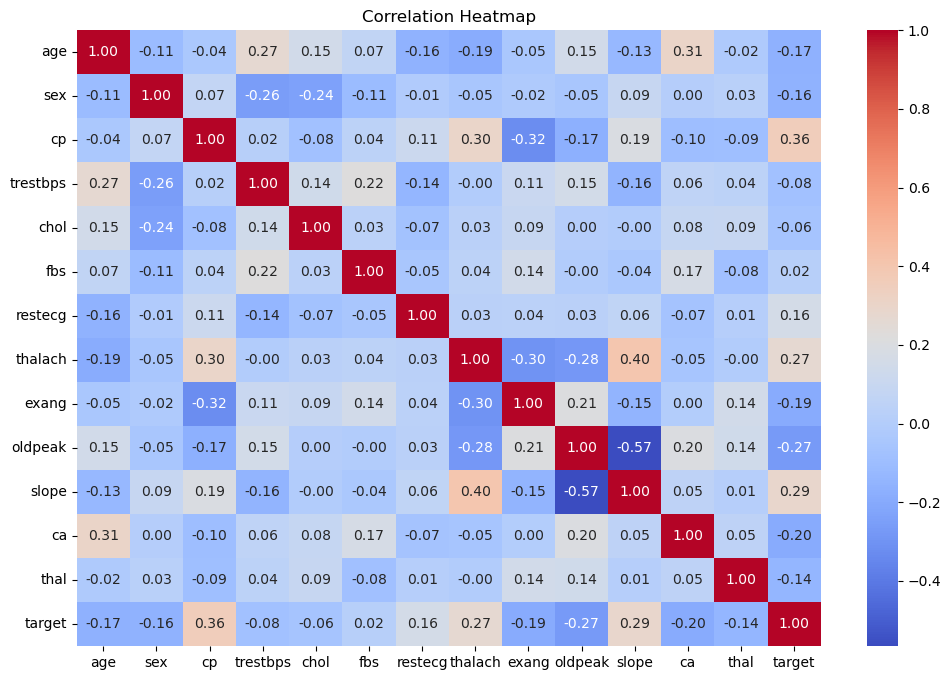

In [76]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

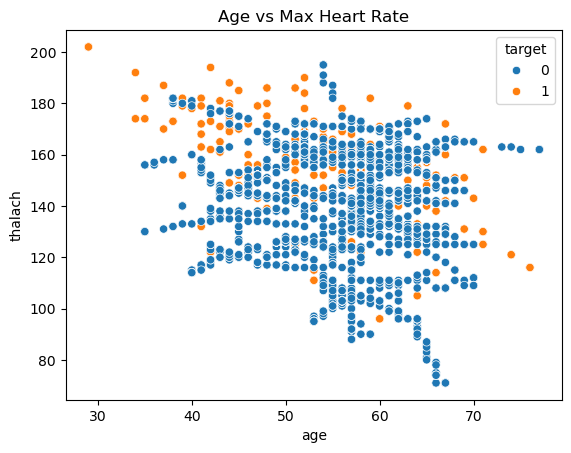

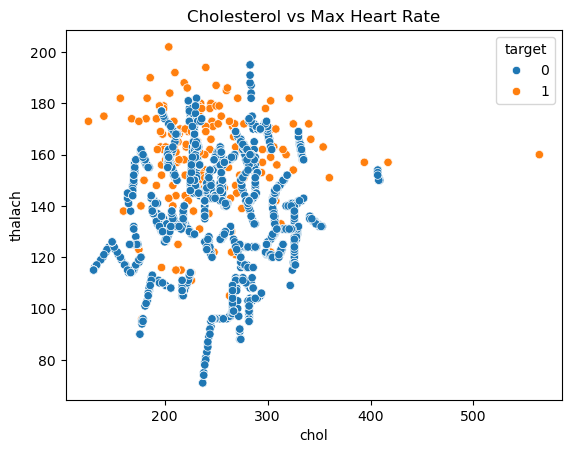

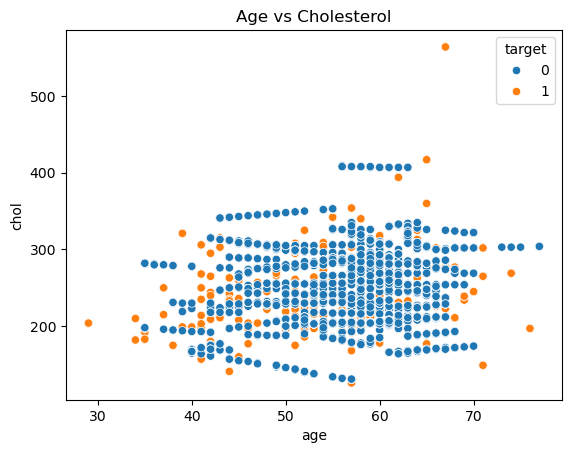

In [18]:
sns.scatterplot(data=df, x='age', y='thalach', hue='target')
plt.title("Age vs Max Heart Rate")
plt.show()

sns.scatterplot(data=df, x='chol', y='thalach', hue='target')
plt.title("Cholesterol vs Max Heart Rate")
plt.show()

sns.scatterplot(data=df, x='age', y='chol', hue='target')
plt.title("Age vs Cholesterol")
plt.show()

# Encoding & Feature Selection

In [19]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [20]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Train/Test Split & Scaling

In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Decision Tree Feature Importance

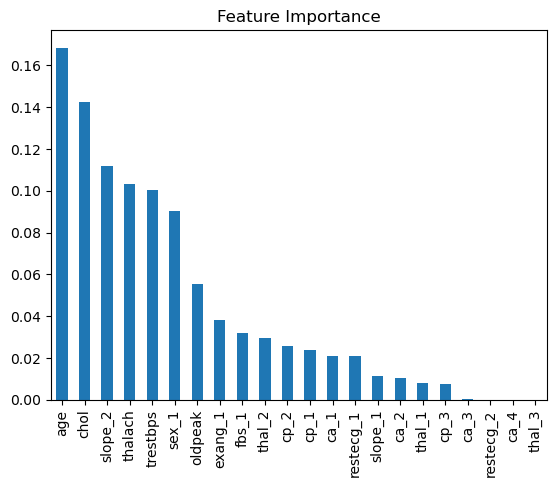

In [23]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

importance = pd.Series(

    dt.feature_importances_,

    index=X.columns

)

importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance")

plt.show()

## Logistic Regression (Before Balancing)

Logistic Regression - Before Balancing
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       865
           1       0.80      0.63      0.70       105

    accuracy                           0.94       970
   macro avg       0.88      0.80      0.84       970
weighted avg       0.94      0.94      0.94       970



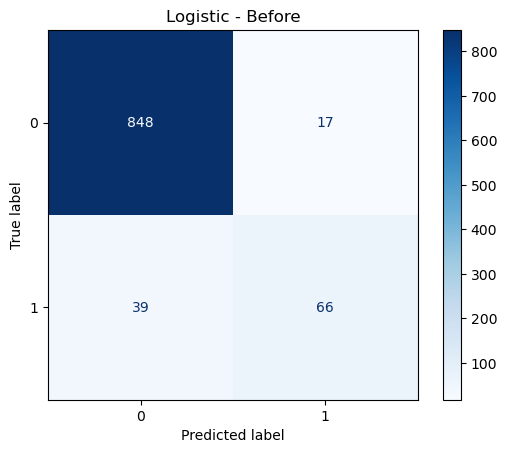

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression - Before Balancing")
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic - Before")
plt.show()

# Logistic Regression (Class Weight)

Logistic Regression - Class Weight
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       865
           1       0.43      0.93      0.59       105

    accuracy                           0.86       970
   macro avg       0.71      0.89      0.75       970
weighted avg       0.93      0.86      0.88       970



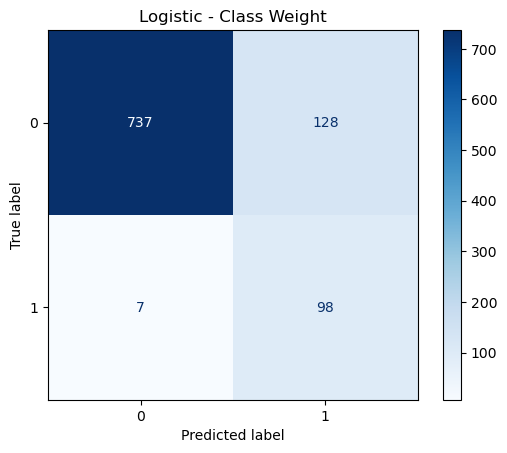

In [25]:
lr_weight = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_weight.fit(X_train_scaled, y_train)

y_pred_lr_weight = lr_weight.predict(X_test_scaled)

print("Logistic Regression - Class Weight")
print(classification_report(y_test, y_pred_lr_weight))

cm = confusion_matrix(y_test, y_pred_lr_weight)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic - Class Weight")
plt.show()

# Logistic Regression (SMOTE)

C:\Users\shaza_hm8\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shaza_hm8\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\shaza_hm8\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shaza_hm8\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^

Logistic Regression - SMOTE
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       865
           1       0.46      0.93      0.62       105

    accuracy                           0.88       970
   macro avg       0.73      0.90      0.77       970
weighted avg       0.93      0.88      0.89       970



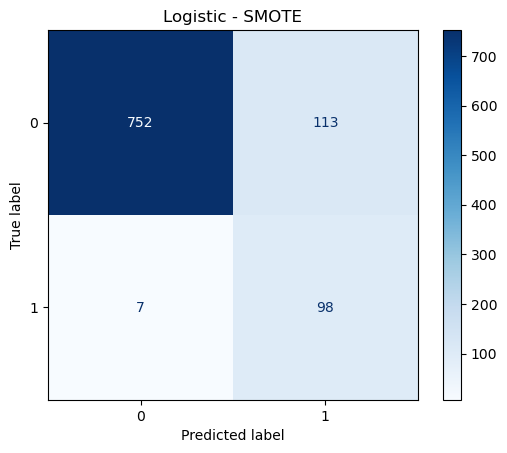

In [26]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_smote, y_smote)

y_pred_lr_smote = lr_smote.predict(X_test_scaled)

print("Logistic Regression - SMOTE")
print(classification_report(y_test, y_pred_lr_smote))

cm = confusion_matrix(y_test, y_pred_lr_smote)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic - SMOTE")
plt.show()

# Logistic Regression (SMOTE Tomek)

Logistic Regression - SMOTE Tomek
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       865
           1       0.46      0.93      0.62       105

    accuracy                           0.88       970
   macro avg       0.73      0.90      0.77       970
weighted avg       0.93      0.88      0.89       970



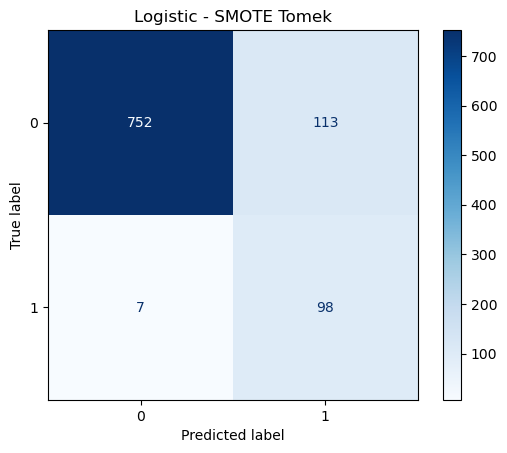

In [27]:
smt = SMOTETomek(random_state=42)

X_smt, y_smt = smt.fit_resample(X_train_scaled, y_train)

lr_smt = LogisticRegression(max_iter=1000)

lr_smt.fit(X_smt, y_smt)

y_pred_lr_smt = lr_smt.predict(X_test_scaled)

print("Logistic Regression - SMOTE Tomek")
print(classification_report(y_test, y_pred_lr_smt))

cm = confusion_matrix(y_test, y_pred_lr_smt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Logistic - SMOTE Tomek")
plt.show()

# Logistic Regression (SMOTE ENN)

Logistic Regression - SMOTE ENN
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       865
           1       0.46      0.93      0.62       105

    accuracy                           0.88       970
   macro avg       0.73      0.90      0.77       970
weighted avg       0.93      0.88      0.89       970



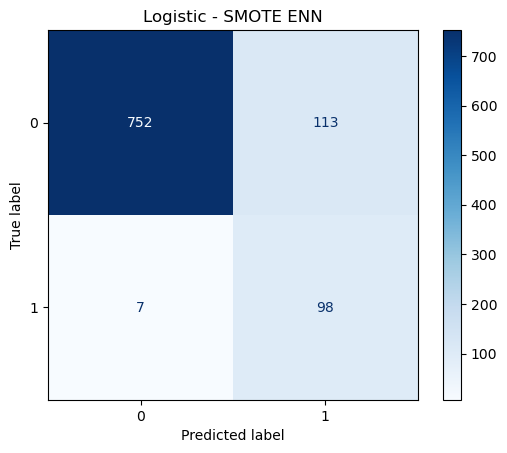

In [28]:
sme = SMOTEENN(random_state=42)

X_sme, y_sme = sme.fit_resample(X_train_scaled, y_train)

lr_sme = LogisticRegression(max_iter=1000)

lr_sme.fit(X_sme, y_sme)

y_pred_lr_sme = lr_sme.predict(X_test_scaled)

print("Logistic Regression - SMOTE ENN")
print(classification_report(y_test, y_pred_lr_sme))

cm = confusion_matrix(y_test, y_pred_lr_sme)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Logistic - SMOTE ENN")
plt.show()

# Decision Tree (Before Balancing)

Decision Tree - Before Balancing
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       0.99      0.97      0.98       105

    accuracy                           1.00       970
   macro avg       0.99      0.99      0.99       970
weighted avg       1.00      1.00      1.00       970



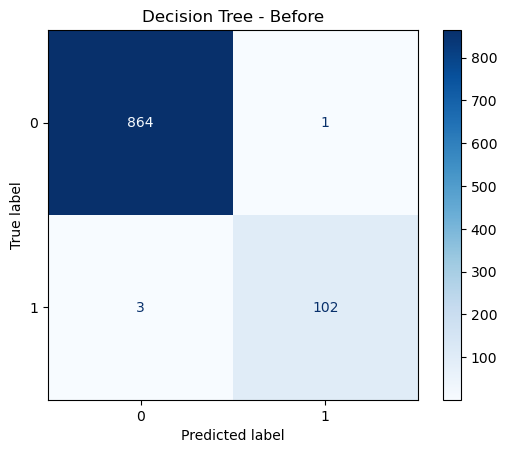

In [29]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree - Before Balancing")
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Decision Tree - Before")
plt.show()

# Decision Tree (Class Weight)

Decision Tree - Class Weight
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       0.99      0.97      0.98       105

    accuracy                           1.00       970
   macro avg       0.99      0.99      0.99       970
weighted avg       1.00      1.00      1.00       970



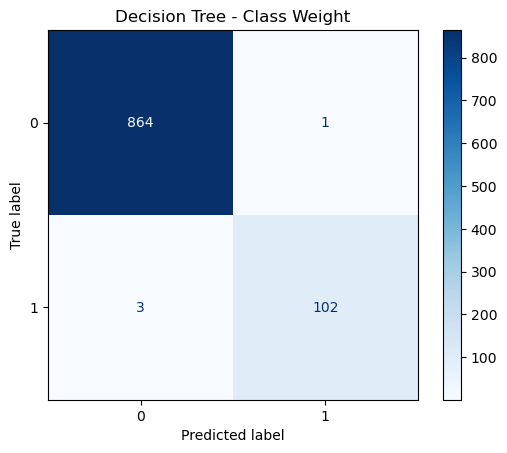

In [30]:
dt_weight = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt_weight.fit(X_train, y_train)

y_pred_dt_weight = dt_weight.predict(X_test)

print("Decision Tree - Class Weight")
print(classification_report(y_test, y_pred_dt_weight))

cm = confusion_matrix(y_test, y_pred_dt_weight)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Decision Tree - Class Weight")
plt.show()

# Decision Tree (SMOTE)

Decision Tree - SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       0.98      0.97      0.98       105

    accuracy                           0.99       970
   macro avg       0.99      0.98      0.99       970
weighted avg       0.99      0.99      0.99       970



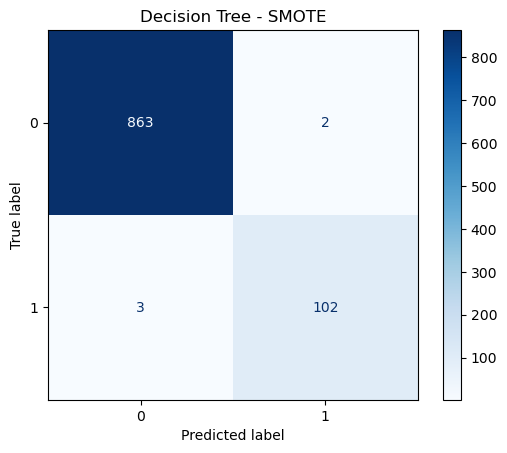

In [31]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

dt_smote = DecisionTreeClassifier(random_state=42)

dt_smote.fit(X_smote, y_smote)

y_pred_dt_smote = dt_smote.predict(X_test)

print("Decision Tree - SMOTE")
print(classification_report(y_test, y_pred_dt_smote))

cm = confusion_matrix(y_test, y_pred_dt_smote)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Decision Tree - SMOTE")
plt.show()

# Decision Tree (SMOTE Tomek)

Decision Tree - SMOTE Tomek
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       0.98      0.97      0.98       105

    accuracy                           0.99       970
   macro avg       0.99      0.98      0.99       970
weighted avg       0.99      0.99      0.99       970



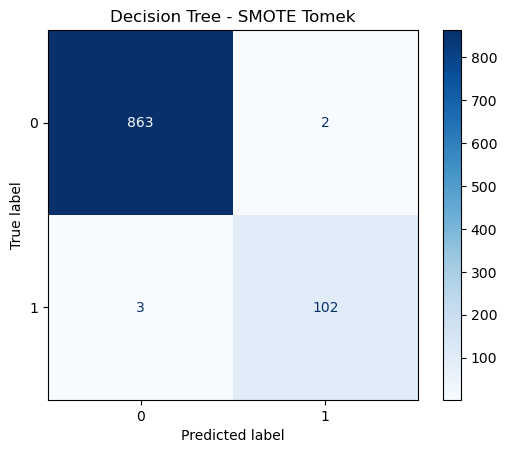

In [32]:
smt = SMOTETomek(random_state=42)

X_smt, y_smt = smt.fit_resample(X_train, y_train)

dt_smt = DecisionTreeClassifier(random_state=42)

dt_smt.fit(X_smt, y_smt)

y_pred_dt_smt = dt_smt.predict(X_test)

print("Decision Tree - SMOTE Tomek")
print(classification_report(y_test, y_pred_dt_smt))

cm = confusion_matrix(y_test, y_pred_dt_smt)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Decision Tree - SMOTE Tomek")
plt.show()

# Decision Tree (SMOTE ENN)

Decision Tree - SMOTE ENN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       0.98      0.97      0.98       105

    accuracy                           0.99       970
   macro avg       0.99      0.98      0.99       970
weighted avg       0.99      0.99      0.99       970



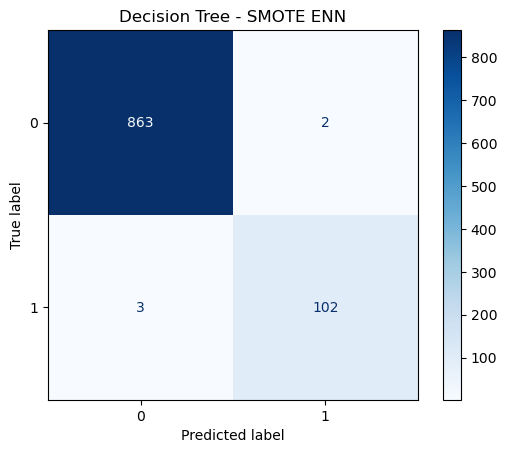

In [33]:
sme = SMOTEENN(random_state=42)

X_sme, y_sme = sme.fit_resample(X_train, y_train)

dt_sme = DecisionTreeClassifier(random_state=42)

dt_sme.fit(X_sme, y_sme)

y_pred_dt_sme = dt_sme.predict(X_test)

print("Decision Tree - SMOTE ENN")
print(classification_report(y_test, y_pred_dt_sme))

cm = confusion_matrix(y_test, y_pred_dt_sme)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Decision Tree - SMOTE ENN")
plt.show()

# Model Evaluation

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models_predictions = {
    "Logistic Before": y_pred_lr,
    "Logistic Class Weight": y_pred_lr_weight,
    "Logistic SMOTE": y_pred_lr_smote,
    "Logistic SMOTE Tomek": y_pred_lr_smt,
    "Logistic SMOTE ENN": y_pred_lr_sme,
    "DT Before": y_pred_dt,
    "DT Class Weight": y_pred_dt_weight,
    "DT SMOTE": y_pred_dt_smote,
    "DT SMOTE Tomek": y_pred_dt_smt,
    "DT SMOTE ENN": y_pred_dt_sme
}

for model_name, y_pred in models_predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Before,0.942268,0.795181,0.628571,0.702128
1,Logistic Class Weight,0.860825,0.433628,0.933333,0.592145
2,Logistic SMOTE,0.876289,0.464455,0.933333,0.620253
3,Logistic SMOTE Tomek,0.876289,0.464455,0.933333,0.620253
4,Logistic SMOTE ENN,0.876289,0.464455,0.933333,0.620253
5,DT Before,0.995876,0.990291,0.971429,0.980769
6,DT Class Weight,0.995876,0.990291,0.971429,0.980769
7,DT SMOTE,0.994845,0.980769,0.971429,0.976077
8,DT SMOTE Tomek,0.994845,0.980769,0.971429,0.976077
9,DT SMOTE ENN,0.994845,0.980769,0.971429,0.976077
